In [1]:
#if locally done
# !pip install tensorflow

In [11]:
import tensorflow as tf
import urllib.request
import zipfile
import tensorflow_datasets as tfds

In [12]:
# 'rock_paper_scissors' dataset download and load
(train_ds, eval_ds), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,  # (image, label)
    with_info=True
)

# see the class names (Rock, Paper, Scissors)
CLASS_NAMES = ds_info.features['label'].names
print(f"Classes found: {CLASS_NAMES}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.PKJMZK_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.PKJMZK_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
Classes found: ['rock', 'paper', 'scissors']


In [13]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

In [14]:

def format_image(image, label):
    # to do the normalization
    image = tf.cast(image, tf.float32) / 255.0
    # resize the image for 224*224
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    return image, label

# Dataset
train_dataset = train_ds.map(format_image).batch(16).prefetch(tf.data.AUTOTUNE)
eval_dataset = eval_ds.map(format_image).batch(16).prefetch(tf.data.AUTOTUNE)

print("done the process")

done the process


In [15]:
from tensorflow import keras

In [18]:
model = keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(IMG_HEIGHT,IMG_WIDTH, 3)),
        keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
    ]
)

In [20]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │       451,587 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 451,587 (1.72 MB)

 Trainable params: 451,587 (1.72 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
EPOCHS = 10
history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.5619 - loss: 16.6859 - val_accuracy: 0.4274 - val_loss: 11.8004
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.7393 - loss: 4.8319 - val_accuracy: 0.4597 - val_loss: 15.0912
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8298 - loss: 2.9036 - val_accuracy: 0.4651 - val_loss: 18.0073
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.8397 - loss: 2.6795 - val_accuracy: 0.5269 - val_loss: 13.6356
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8722 - loss: 1.8778 - val_accuracy: 0.4597 - val_loss: 18.6338
Epoch 6/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8329 - loss: 3.4271 - val_accuracy: 0.5887 - val_loss: 12.8679
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.9313 - loss: 0.9138 - val_accuracy: 0.5027 - val_loss: 28.3179
Epoch 8/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8889 - loss: 1.8322 

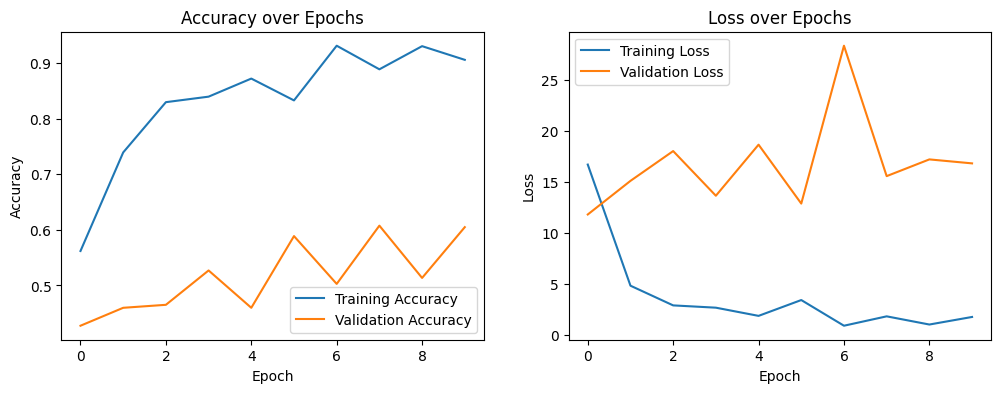

In [24]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

overfitting ?


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


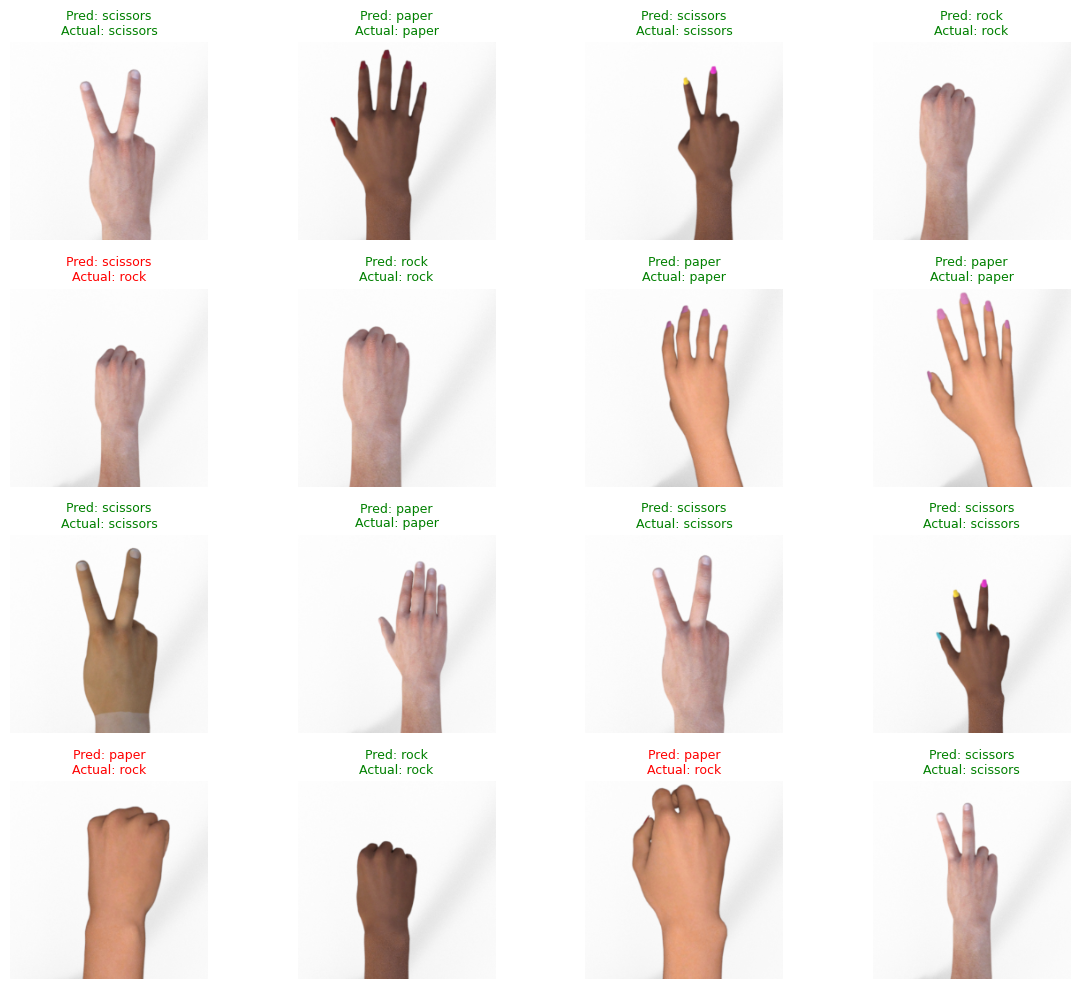

In [26]:
import numpy as np
import math

for images, labels in eval_dataset.take(1):
    predictions = model.predict(images)
    predicted_indices = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12, 10))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i])

        pred_name = CLASS_NAMES[predicted_indices[i]]
        actual_name = CLASS_NAMES[labels[i]]


        color = "green" if pred_name == actual_name else "red"
        plt.title(f"Pred: {pred_name}\nActual: {actual_name}", color=color, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()